In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/diabetic_data_cleaned.csv", low_memory=False)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (101766, 50)


In [2]:
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

print(df["readmitted_30"].value_counts())

readmitted_30
0    90409
1    11357
Name: count, dtype: int64


In [1]:
print(df.shape)
print(df["readmitted_30"].value_counts())

NameError: name 'df' is not defined

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/diabetic_data_cleaned.csv", low_memory=False)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (101766, 50)


In [3]:
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

print(df["readmitted_30"].value_counts())

readmitted_30
0    90409
1    11357
Name: count, dtype: int64


In [4]:
print(df.shape)
print(df["readmitted_30"].value_counts())

(101766, 51)
readmitted_30
0    90409
1    11357
Name: count, dtype: int64


In [5]:
df = df.drop(columns=["readmitted"])

print(df.shape)

(101766, 50)


In [6]:
print("readmitted" in df.columns)
print("readmitted_30" in df.columns)

False
True


In [7]:
df = df.drop(columns=["encounter_id", "patient_nbr"])

print(df.shape)

(101766, 48)


In [8]:
print("encounter_id" in df.columns)
print("patient_nbr" in df.columns)

False
False


In [9]:
missing = df.isnull().sum()

print(missing[missing > 0].sort_values(ascending=False))

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


In [10]:
high_missing_cols = [
    "weight",
    "max_glu_serum",
    "A1Cresult",
    "medical_specialty",
    "payer_code"
]

df = df.drop(columns=high_missing_cols)

print(df.shape)

(101766, 43)


In [11]:
print(df.isnull().sum()[df.isnull().sum() > 0])

race      2273
diag_1      21
diag_2     358
diag_3    1423
dtype: int64


In [12]:
df["race"] = df["race"].fillna("Unknown")

print(df["race"].value_counts())

race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


In [13]:
diagnosis_cols = ["diag_1", "diag_2", "diag_3"]

for col in diagnosis_cols:
    df[col] = df[col].fillna("Unknown")

print(df[diagnosis_cols].isnull().sum())

diag_1    0
diag_2    0
diag_3    0
dtype: int64


In [14]:
missing = df.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [15]:
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Categorical columns:")
print(categorical_cols.tolist())

print("\nNumber of categorical columns:", len(categorical_cols))

Categorical columns:
['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

Number of categorical columns: 31


C:\Users\rgukt\AppData\Local\Temp\ipykernel_13780\3352183633.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [16]:
numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical columns:")
print(numerical_cols.tolist())

print("\nNumber of numerical columns:", len(numerical_cols))

Numerical columns:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'readmitted_30']

Number of numerical columns: 12


In [1]:
X = df.drop(columns=["readmitted_30"])
y = df["readmitted_30"]

print("X shape:", X.shape)
print("y shape:", y.shape)

NameError: name 'df' is not defined

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/diabetic_data_cleaned.csv", low_memory=False)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (101766, 50)


In [3]:
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

print(df["readmitted_30"].value_counts())

readmitted_30
0    90409
1    11357
Name: count, dtype: int64


In [4]:
X = df.drop(columns=["readmitted_30"])
y = df["readmitted_30"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (101766, 50)
y shape: (101766,)


In [5]:
print(y.value_counts())

readmitted_30
0    90409
1    11357
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (81412, 50)
X_test: (20354, 50)
y_train: (81412,)
y_test: (20354,)


In [7]:
print("Total columns:", len(df.columns))
print(df.columns.tolist())

Total columns: 51
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'readmitted_30']


In [8]:
df = df.drop(columns=["readmitted"])

In [9]:
df = df.drop(columns=["encounter_id", "patient_nbr"])

In [10]:
high_missing_cols = [
    "weight",
    "max_glu_serum",
    "A1Cresult",
    "medical_specialty",
    "payer_code"
]

df = df.drop(columns=high_missing_cols)

In [11]:
df["race"] = df["race"].fillna("Unknown")

diagnosis_cols = ["diag_1", "diag_2", "diag_3"]

for col in diagnosis_cols:
    df[col] = df[col].fillna("Unknown")

In [12]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nColumns:", len(df.columns))

Shape: (101766, 43)

Missing values:
Series([], dtype: int64)

Columns: 43


In [13]:
X = df.drop(columns=["readmitted_30"])
y = df["readmitted_30"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (101766, 42)
y shape: (101766,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (81412, 42)
X_test: (20354, 42)
y_train: (81412,)
y_test: (20354,)


In [15]:
categorical_cols = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Number of categorical columns:", len(categorical_cols))
print(categorical_cols)

Number of categorical columns: 31
['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [16]:
numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Number of numerical columns:", len(numerical_cols))
print(numerical_cols)

Number of numerical columns: 11
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


In [17]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

print("X_train categorical shape:", X_train_cat.shape)
print("X_test categorical shape:", X_test_cat.shape)

X_train categorical shape: (81412, 2262)
X_test categorical shape: (20354, 2262)


In [18]:
X_train_num = X_train[numerical_cols].values
X_test_num = X_test[numerical_cols].values

X_train_final = np.hstack([X_train_num, X_train_cat])
X_test_final = np.hstack([X_test_num, X_test_cat])

print("Final X_train shape:", X_train_final.shape)
print("Final X_test shape:", X_test_final.shape)

Final X_train shape: (81412, 2273)
Final X_test shape: (20354, 2273)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_final[:, :len(numerical_cols)] = scaler.fit_transform(
    X_train_final[:, :len(numerical_cols)]
)

X_test_final[:, :len(numerical_cols)] = scaler.transform(
    X_test_final[:, :len(numerical_cols)]
)

print("Scaling completed!")

Scaling completed!


In [1]:
import os

os.makedirs("../data/processed", exist_ok=True)

np.save("../data/processed/X_train.npy", X_train_final)
np.save("../data/processed/X_test.npy", X_test_final)
np.save("../data/processed/y_train.npy", y_train.values)
np.save("../data/processed/y_test.npy", y_test.values)

print("Processed data saved successfully!")


NameError: name 'np' is not defined

In [2]:
import numpy as np

In [3]:
import os

os.makedirs("../data/processed", exist_ok=True)

np.save("../data/processed/X_train.npy", X_train_final)
np.save("../data/processed/X_test.npy", X_test_final)
np.save("../data/processed/y_train.npy", y_train.values)
np.save("../data/processed/y_test.npy", y_test.values)

print("Processed data saved successfully!")

NameError: name 'X_train_final' is not defined

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/diabetic_data_cleaned.csv", low_memory=False)

print(df.shape)

(101766, 50)


In [5]:
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)
df = df.drop(columns=["readmitted"])

In [6]:
df = df.drop(columns=["encounter_id", "patient_nbr"])

high_missing_cols = [
    "weight",
    "max_glu_serum",
    "A1Cresult",
    "medical_specialty",
    "payer_code"
]

df = df.drop(columns=high_missing_cols)

In [7]:
df["race"] = df["race"].fillna("Unknown")

diagnosis_cols = ["diag_1", "diag_2", "diag_3"]

for col in diagnosis_cols:
    df[col] = df[col].fillna("Unknown")

print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [8]:
X = df.drop(columns=["readmitted_30"])
y = df["readmitted_30"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
categorical_cols = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(len(categorical_cols))
print(len(numerical_cols))

31
11


In [11]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

print(X_train_cat.shape)

(81412, 2262)


In [12]:
X_train_num = X_train[numerical_cols].values
X_test_num = X_test[numerical_cols].values

X_train_final = np.hstack([X_train_num, X_train_cat])
X_test_final = np.hstack([X_test_num, X_test_cat])

print(X_train_final.shape)
print(X_test_final.shape)

(81412, 2273)
(20354, 2273)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_final[:, :len(numerical_cols)] = scaler.fit_transform(
    X_train_final[:, :len(numerical_cols)]
)

X_test_final[:, :len(numerical_cols)] = scaler.transform(
    X_test_final[:, :len(numerical_cols)]
)

print("Scaling completed!")

Scaling completed!


In [14]:
import os

os.makedirs("../data/processed", exist_ok=True)

np.save("../data/processed/X_train.npy", X_train_final)
np.save("../data/processed/X_test.npy", X_test_final)
np.save("../data/processed/y_train.npy", y_train.values)
np.save("../data/processed/y_test.npy", y_test.values)

print("Processed data saved successfully!")

Processed data saved successfully!


In [1]:
categorical_feature_names = encoder.get_feature_names_out(categorical_cols)

print("Number of categorical feature names:", len(categorical_feature_names))
print(categorical_feature_names[:20])

NameError: name 'encoder' is not defined

In [2]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])

print("Categorical features:", X_train_cat.shape)

NameError: name 'X_train' is not defined

In [3]:
import numpy as np

X_train = np.load("../data/processed/X_train.npy")
X_test = np.load("../data/processed/X_test.npy")
y_train = np.load("../data/processed/y_train.npy")
y_test = np.load("../data/processed/y_test.npy")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (81412, 2273)
X_test: (20354, 2273)


In [4]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [5]:
categorical_feature_names = encoder.get_feature_names_out(categorical_cols)

feature_names = list(numerical_cols) + list(categorical_feature_names)

print("Categorical feature names:", len(categorical_feature_names))
print("Total feature names:", len(feature_names))

NameError: name 'categorical_cols' is not defined

In [6]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print(categorical_cols)

AttributeError: 'numpy.ndarray' object has no attribute 'select_dtypes'

In [7]:
categorical_cols = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

AttributeError: 'numpy.ndarray' object has no attribute 'select_dtypes'

In [8]:
from sklearn.model_selection import train_test_split

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train_df:", X_train_df.shape)
print("X_test_df:", X_test_df.shape)

NameError: name 'X' is not defined

In [1]:
import pandas as pd

df = pd.read_csv("../data/diabetic_data_cleaned.csv", low_memory=False)

print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (101766, 50)


In [2]:
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

print(df["readmitted_30"].value_counts())

readmitted_30
0    90409
1    11357
Name: count, dtype: int64


In [3]:
X = df.drop(columns=["readmitted", "readmitted_30"])
y = df["readmitted_30"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (101766, 49)
y shape: (101766,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (81412, 49)
X_test: (20354, 49)
y_train: (81412,)
y_test: (20354,)


In [5]:
categorical_cols = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Number of categorical columns:", len(categorical_cols))
print("Number of numerical columns:", len(numerical_cols))

Number of categorical columns: 36
Number of numerical columns: 13


In [6]:
print("All columns:")
print(X_train.columns.tolist())

All columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [7]:
drop_cols = [
    "encounter_id",
    "patient_nbr",
    "weight",
    "payer_code",
    "medical_specialty",
    "max_glu_serum",
    "A1Cresult"
]

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (81412, 42)
X_test shape: (20354, 42)


In [8]:
categorical_cols = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Number of categorical columns:", len(categorical_cols))
print("Number of numerical columns:", len(numerical_cols))

Number of categorical columns: 31
Number of numerical columns: 11


In [9]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

print("X_train categorical shape:", X_train_cat.shape)
print("X_test categorical shape:", X_test_cat.shape)

X_train categorical shape: (81412, 2262)
X_test categorical shape: (20354, 2262)


In [10]:
categorical_feature_names = encoder.get_feature_names_out(categorical_cols)

feature_names = list(numerical_cols) + list(categorical_feature_names)

print("Categorical feature names:", len(categorical_feature_names))
print("Total feature names:", len(feature_names))

Categorical feature names: 2262
Total feature names: 2273


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_test_num = scaler.transform(X_test[numerical_cols])

X_train_final = __import__("numpy").hstack([X_train_num, X_train_cat])
X_test_final = __import__("numpy").hstack([X_test_num, X_test_cat])

print("Final X_train shape:", X_train_final.shape)
print("Final X_test shape:", X_test_final.shape)

Final X_train shape: (81412, 2273)
Final X_test shape: (20354, 2273)


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_final, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [13]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance.head(10))

                     feature  importance
4         num_lab_procedures    0.053369
6            num_medications    0.048905
9           number_inpatient    0.040696
3           time_in_hospital    0.039001
1   discharge_disposition_id    0.031145
10          number_diagnoses    0.027827
5             num_procedures    0.027477
0          admission_type_id    0.020778
2        admission_source_id    0.018327
7          number_outpatient    0.013847


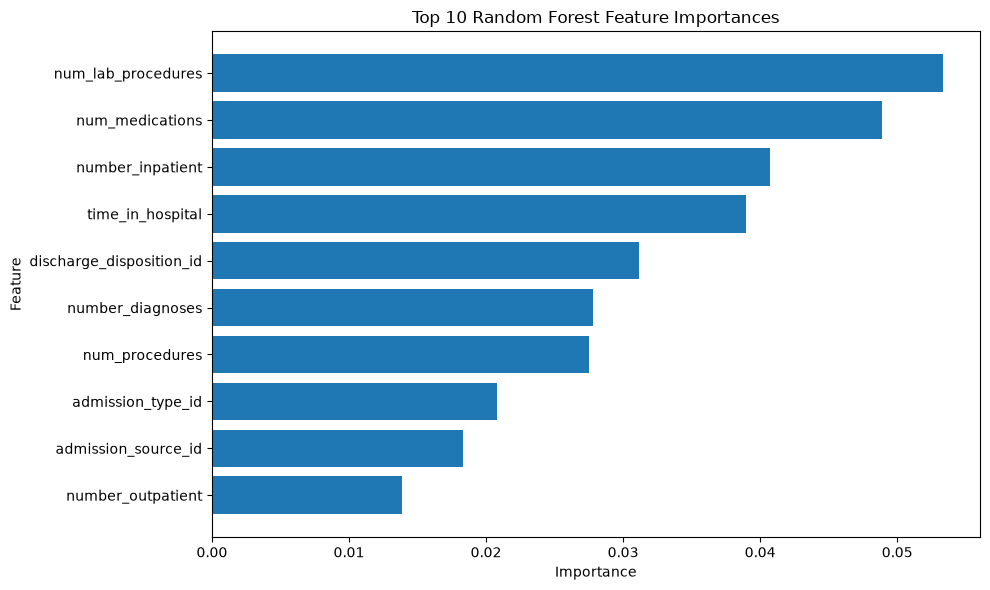

In [14]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10).sort_values(
    by="importance"
)

plt.figure(figsize=(10, 6))
plt.barh(top10["feature"], top10["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [15]:
import os

os.makedirs("../data/processed", exist_ok=True)

feature_importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [16]:
print(feature_importance.head(10))

                     feature  importance
4         num_lab_procedures    0.053369
6            num_medications    0.048905
9           number_inpatient    0.040696
3           time_in_hospital    0.039001
1   discharge_disposition_id    0.031145
10          number_diagnoses    0.027827
5             num_procedures    0.027477
0          admission_type_id    0.020778
2        admission_source_id    0.018327
7          number_outpatient    0.013847
